<a href="https://colab.research.google.com/github/2403a52026-lgtm/NLP.LabAssignments/blob/main/NLP_LAB12_4_textcnn_pretrainedEmbeddings_T_Abhishek_2403a52026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
# ==========================================
# STEP 1 — IMPORT LIBRARIES
# ==========================================

import numpy as np
import pandas as pd
import re
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from torch.utils.data import Dataset, DataLoader


In [68]:
# ==========================================
# STEP 2 — LOAD DATASET
# ==========================================

df = pd.read_csv("SMSSpamCollection", sep="\t", header=None)
df.columns = ["label", "text"]

# Convert labels to binary
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print(df['label'].value_counts())


label
0    4825
1     747
Name: count, dtype: int64


In [69]:
# ==========================================
# STEP 3 — CLEAN TEXT
# ==========================================

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['text'] = df['text'].apply(clean_text)


In [70]:
# ==========================================
# STEP 4 — TOKENIZATION
# ==========================================

df['tokens'] = df['text'].apply(lambda x: x.split())


In [71]:
# ==========================================
# STEP 5 — BUILD VOCABULARY
# ==========================================

vocab = {"<PAD>": 0, "<UNK>": 1}
index = 2

for tokens in df['tokens']:
    for word in tokens:
        if word not in vocab:
            vocab[word] = index
            index += 1

print("Vocabulary Size:", len(vocab))


Vocabulary Size: 8631


In [72]:
# ==========================================
# STEP 6 — ENCODING + PADDING
# ==========================================

max_len = 50

def encode(tokens):
    seq = [vocab.get(word, vocab["<UNK>"]) for word in tokens]

    if len(seq) < max_len:
        seq += [0] * (max_len - len(seq))
    else:
        seq = seq[:max_len]

    return seq

df['encoded'] = df['tokens'].apply(encode)


In [73]:
# ==========================================
# STEP 7 — TRAIN TEST SPLIT
# ==========================================

X = np.array(df['encoded'].tolist())
y = np.array(df['label'].tolist())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [74]:
# ==========================================
# STEP 8 — LOAD GLOVE EMBEDDINGS
# ==========================================

embedding_dim = 100

embedding_matrix = np.random.uniform(-0.25, 0.25, (len(vocab), embedding_dim))

with open("glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')

        if word in vocab:
            idx = vocab[word]
            embedding_matrix[idx] = vector


In [75]:
# ==========================================
# STEP 9 — DATASET CLASS
# ==========================================

class SMSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = SMSDataset(X_train, y_train)
test_dataset = SMSDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)


In [76]:
# ==========================================
# STEP 10 — CNN MODEL
# ==========================================

class TextCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, embedding_matrix):
        super(TextCNN, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight = nn.Parameter(
            torch.tensor(embedding_matrix, dtype=torch.float32)
        )
        self.embedding.weight.requires_grad = False

        self.conv1 = nn.Conv1d(embedding_dim, 128, kernel_size=3)
        self.conv2 = nn.Conv1d(embedding_dim, 128, kernel_size=4)
        self.conv3 = nn.Conv1d(embedding_dim, 128, kernel_size=5)

        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(128 * 3, 1)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)

        c1 = torch.relu(self.conv1(x))
        c1 = torch.max_pool1d(c1, c1.shape[2]).squeeze(2)

        c2 = torch.relu(self.conv2(x))
        c2 = torch.max_pool1d(c2, c2.shape[2]).squeeze(2)

        c3 = torch.relu(self.conv3(x))
        c3 = torch.max_pool1d(c3, c3.shape[2]).squeeze(2)

        x = torch.cat((c1, c2, c3), 1)
        x = self.dropout(x)
        x = torch.sigmoid(self.fc(x))

        return x


In [77]:
# ==========================================
# STEP 11 — TRAINING
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TextCNN(len(vocab), embedding_dim, embedding_matrix).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
loss_list = []
accuracy_list = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_list.append(avg_loss)

    # Evaluate accuracy each epoch
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs).squeeze()
            preds = (outputs > 0.5).int().cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    accuracy_list.append(acc)

    print(f"Epoch {epoch+1}, Loss: {avg_loss}, Accuracy: {acc}")


Epoch 1, Loss: 0.2552784623844283, Accuracy: 0.9479820627802691
Epoch 2, Loss: 0.10061584391764232, Accuracy: 0.9632286995515695
Epoch 3, Loss: 0.06365163909005267, Accuracy: 0.9721973094170404
Epoch 4, Loss: 0.04854039641629372, Accuracy: 0.97847533632287
Epoch 5, Loss: 0.0347886195805456, Accuracy: 0.9775784753363229
Epoch 6, Loss: 0.03117945805591132, Accuracy: 0.9802690582959641
Epoch 7, Loss: 0.02138697242896472, Accuracy: 0.9820627802690582
Epoch 8, Loss: 0.016068331012502313, Accuracy: 0.9811659192825112
Epoch 9, Loss: 0.01268732940245952, Accuracy: 0.9820627802690582
Epoch 10, Loss: 0.009312309646546574, Accuracy: 0.9820627802690582


In [78]:
# ==========================================
# TRAINING CELL
# ==========================================

epochs = 10
loss_list = []
accuracy_list = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_list.append(avg_loss)

    # Evaluate on test set
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs).squeeze()
            preds = (outputs > 0.5).int().cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    accuracy_list.append(acc)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, Accuracy: {acc:.4f}")


Epoch 1, Loss: 0.0070, Accuracy: 0.9821
Epoch 2, Loss: 0.0065, Accuracy: 0.9830
Epoch 3, Loss: 0.0049, Accuracy: 0.9821
Epoch 4, Loss: 0.0045, Accuracy: 0.9821
Epoch 5, Loss: 0.0037, Accuracy: 0.9821
Epoch 6, Loss: 0.0034, Accuracy: 0.9830
Epoch 7, Loss: 0.0029, Accuracy: 0.9830
Epoch 8, Loss: 0.0026, Accuracy: 0.9839
Epoch 9, Loss: 0.0018, Accuracy: 0.9830
Epoch 10, Loss: 0.0016, Accuracy: 0.9830


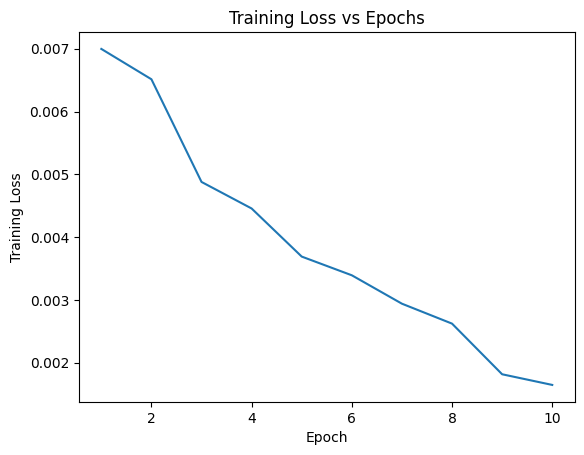

In [79]:
# ==========================================
# GRAPH 1 — TRAINING LOSS
# ==========================================

import matplotlib.pyplot as plt

plt.figure()
plt.plot(range(1, epochs+1), loss_list)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epochs")
plt.show()


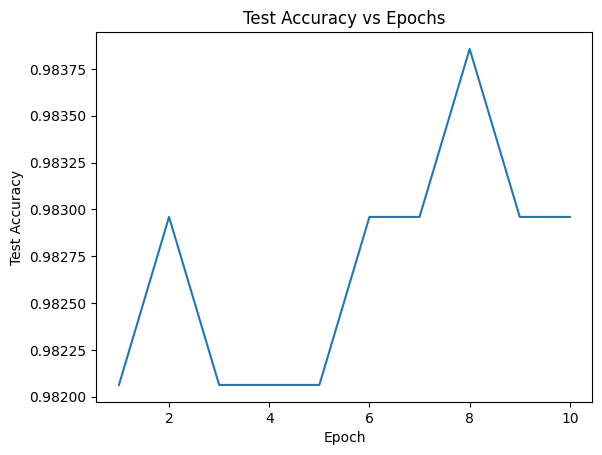

In [80]:
# ==========================================
# GRAPH 2 — TEST ACCURACY
# ==========================================

plt.figure()
plt.plot(range(1, epochs+1), accuracy_list)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs Epochs")
plt.show()


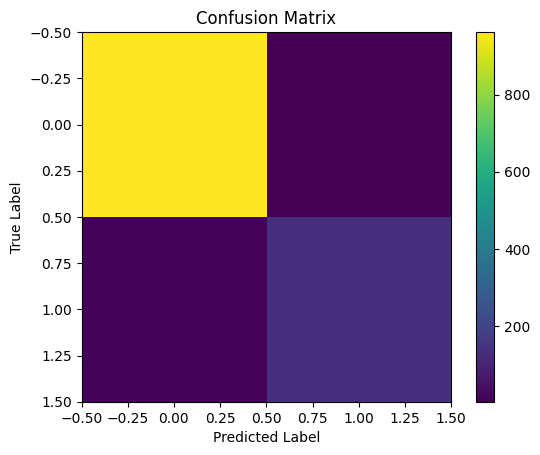

In [81]:
# ==========================================
# GRAPH 3 — CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(all_labels, all_preds)

plt.figure()
plt.imshow(cm)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()
